# Imports

In [ ]:
#!pip install pillow-heif
!pip install -q protobuf==3.20.3


In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import pickle

from PIL import Image
#import pillow_heif

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)
print("Keras version:", keras.__version__)

2026-01-07 16:06:49.962003: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767802010.142239      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767802010.194302      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767802010.607556      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767802010.607602      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767802010.607605      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
OpenCV version: 4.12.0
Keras version: 3.10.0


#

# **dont need to run it** .HEIC to .jpg convert, ,

# Dataset paths

In [1]:
DATA_DIR = '/content/drive/MyDrive/CVPR_practice/data'

if DATA_DIR is None:
    raise Exception("DATA_DIR is None")


In [2]:


CATEGORIES = sorted(os.listdir(DATA_DIR))
output_unit = len(CATEGORIES)

print("Number of classes:", output_unit)
print("Classes:", CATEGORIES)

NameError: name 'os' is not defined

In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50

# Load images

In [ ]:
data = []

for label, category in enumerate(CATEGORIES):
    folder_path = os.path.join(DATA_DIR, category)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append([img, label])
        except:
            print("Error loading:", img_path)


#random.shuffle(data)

Error loading: /content/drive/MyDrive/CVPR_practice/data/21-45902-3/IMG_3395.jpeg
Error loading: /content/drive/MyDrive/CVPR_practice/data/22-46138-1/IMG_2911.jpg
Error loading: /content/drive/MyDrive/CVPR_practice/data/22-46141-1/IMG_2905.jpg


In [ ]:
import pickle

pickle_path = "/content/drive/MyDrive/CVPR_practice/all_data.pkl"

with open(pickle_path, "wb") as f:
    pickle.dump(data, f)

print("Data saved successfully!")


Data saved successfully!


In [3]:
pickle_in = open("/kaggle/input/student-dataset-cvpr/all_student_data.pkl","rb")
data = pickle.load(pickle_in)
print("Total samples:", len(data))


Total samples: 1146


# Shuffle randomly

In [4]:
random.shuffle(data)

# visualize some data


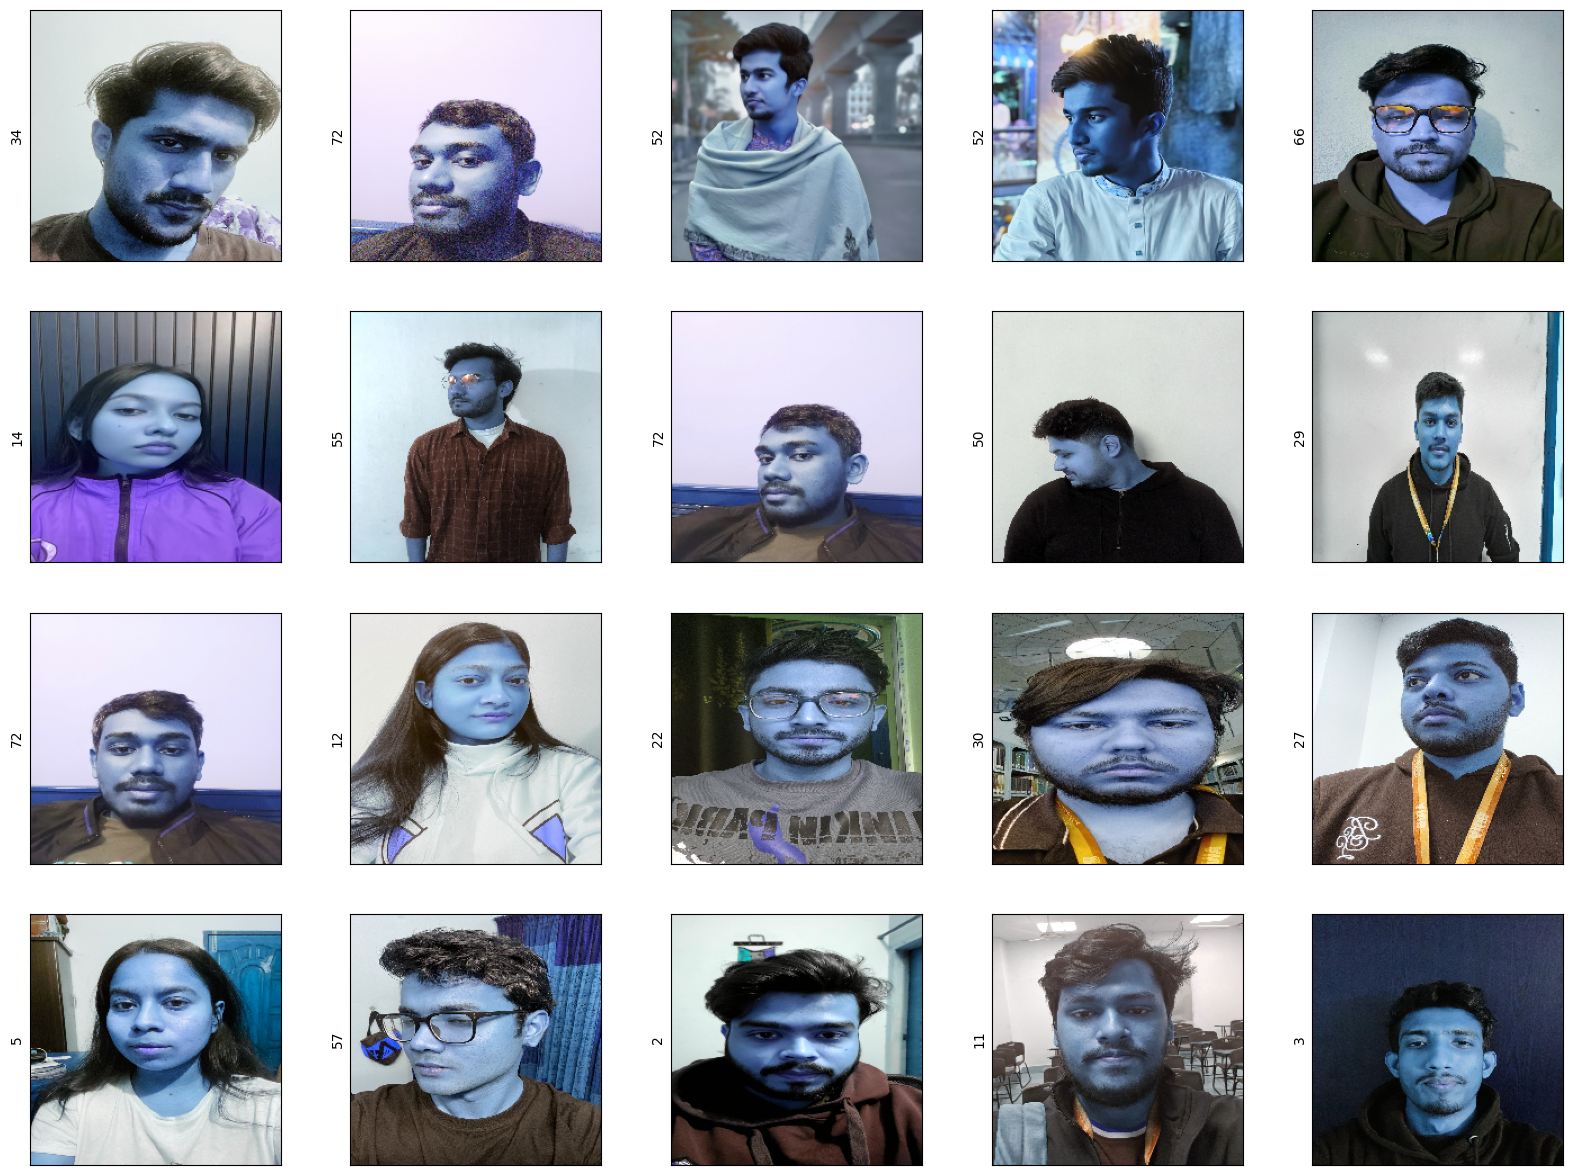

In [20]:
i = 0
plt.figure(figsize=(20,15))

for i in range(20):
    img_data, label = data[i]
    plt.subplot(4,5,i+1)
    plt.imshow(cv2.cvtColor(img_data, cv2.COLOR_BGR2RGB))
    plt.ylabel(label)
    #plt.xlabel(person)
    plt.xticks([])
    plt.yticks([])
plt.show()

In [ ]:
#X = []
#y = []

#for img, label, category in all_data:
   # X.append(img)
    #y.append(label)

#X = np.array(X, dtype="float32")
#y = np.array(y)


# Normalize

In [6]:
images = np.array([x[0] for x in data], dtype="float32") / 255.0
labels = np.array([x[1] for x in data])

split = int(0.8 * len(images))

X_train, X_test = images[:split], images[split:]
Y_train, Y_test = labels[:split], labels[split:]

print("Train:", X_train.shape, Y_train.shape)
print("Test :", X_test.shape, Y_test.shape)


Train: (916, 224, 224, 3) (916,)
Test : (230, 224, 224, 3) (230,)


# Augmentation

In [7]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(X_train, Y_train, batch_size=BATCH_SIZE)
val_generator = val_datagen.flow(X_test, Y_test, batch_size=BATCH_SIZE)


# Model

In [9]:
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # Block 4
    layers.Conv2D(512, (3,3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
   # layers.Dropout(0.5),
    layers.Dense(76, activation='softmax')
])


I0000 00:00:1767802155.132004      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767802155.135935      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Compile

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │   102,761,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 76)             │        77,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,394,188 (398.23 MB)

 Trainable params: 104,392,268 (398.22 MB)

 Non-trainable params: 1,920 (7.50 KB)

# EarlyStopping

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3
    )
]


# Train the Model

In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1767802180.446612     128 service.cc:152] XLA service 0x7a96fc006a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767802180.446652     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767802180.446659     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767802181.025523     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-07 16:09:47.393992: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 16:09:47.565159: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1767802194.506416     128 device_co

 9/29 ━━━━━━━━━━━━━━━━━━━━ 5s 296ms/step - accuracy: 0.0381 - loss: 135.8281

2026-01-07 16:10:01.535669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 16:10:01.702132: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


29/29 ━━━━━━━━━━━━━━━━━━━━ 39s 776ms/step - accuracy: 0.0480 - loss: 130.7071 - val_accuracy: 0.0783 - val_loss: 429.7818 - learning_rate: 0.0010
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 308ms/step - accuracy: 0.1574 - loss: 23.4397 - val_accuracy: 0.0739 - val_loss: 80.4792 - learning_rate: 0.0010
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 332ms/step - accuracy: 0.3336 - loss: 6.7412 - val_accuracy: 0.1217 - val_loss: 10.5028 - learning_rate: 0.0010
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 336ms/step - accuracy: 0.4214 - loss: 3.1804 - val_accuracy: 0.1522 - val_loss: 8.4789 - learning_rate: 0.0010
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 349ms/step - accuracy: 0.5054 - loss: 2.4517 - val_accuracy: 0.2174 - val_loss: 6.3285 - learning_rate: 0.0010
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 343ms/step - accuracy: 0.6236 - loss: 1.9782 - val_accuracy: 0.2609 - val_loss: 5.0316 - learning_rate: 0.0010
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 330ms/step - accuracy: 0.6796 - loss: 1.3594 

In [13]:
predictions = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step


# Save the model

In [15]:
os.makedirs("/kaggle/working/models", exist_ok=True)
model.save("/kaggle/working/models/cnn_face_model_latest.keras")

# Plot Accuracy & Loss

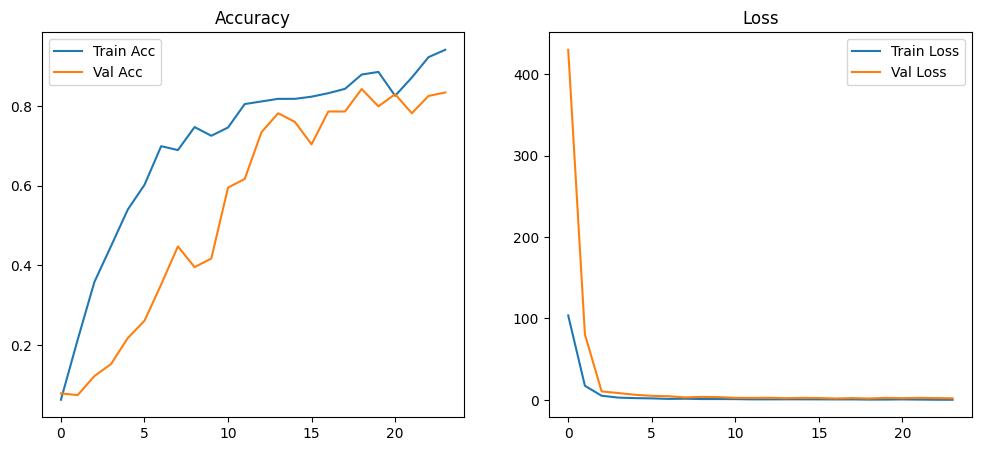

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()


In [ ]:
import pickle
from tqdm import tqdm

pickle_out = open("/content/drive/MyDrive/CVPR_practice/facePikle_X_train","wb")
pickle.dump(X_train, pickle_out)
pickle_out.close()

pickle_out = open("/content/drive/MyDrive/CVPR_practice/facePikle_Y_train","wb")
pickle.dump(Y_train, pickle_out)
pickle_out.close()

pickle_out = open("/content/drive/MyDrive/CVPR_practice/facePikle_X_test","wb")
pickle.dump(X_test, pickle_out)
pickle_out.close()

pickle_out = open("/content/drive/MyDrive/CVPR_practice/facePikle_Y_test","wb")
pickle.dump(Y_test, pickle_out)
pickle_out.close()

# save the labels

In [25]:
import json
label_map = {i: name for i, name in enumerate(CATEGORIES)}

with open("labels.json", "w") as f:
    json.dump(label_map, f)

{0: 34, 1: 72, 2: 52, 3: 52, 4: 66, 5: 14, 6: 55, 7: 72, 8: 50, 9: 29, 10: 72, 11: 12, 12: 22, 13: 30, 14: 27, 15: 5, 16: 57, 17: 2, 18: 11, 19: 3, 20: 56, 21: 56, 22: 7, 23: 20, 24: 21, 25: 16, 26: 72, 27: 16, 28: 71, 29: 14, 30: 2, 31: 70, 32: 40, 33: 34, 34: 72, 35: 51, 36: 57, 37: 68, 38: 73, 39: 12, 40: 28, 41: 31, 42: 34, 43: 10, 44: 67, 45: 36, 46: 13, 47: 16, 48: 65, 49: 59, 50: 56, 51: 62, 52: 5, 53: 64, 54: 68, 55: 72, 56: 28, 57: 15, 58: 45, 59: 45, 60: 3, 61: 28, 62: 34, 63: 1, 64: 36, 65: 30, 66: 52, 67: 60, 68: 27, 69: 18, 70: 72, 71: 18, 72: 31, 73: 51, 74: 60, 75: 21, 76: 13, 77: 34, 78: 60, 79: 72, 80: 55, 81: 14, 82: 58, 83: 58, 84: 20, 85: 67, 86: 69, 87: 8, 88: 69, 89: 62, 90: 50, 91: 63, 92: 48, 93: 15, 94: 16, 95: 64, 96: 70, 97: 28, 98: 21, 99: 74, 100: 68, 101: 1, 102: 1, 103: 22, 104: 27, 105: 66, 106: 66, 107: 36, 108: 28, 109: 2, 110: 46, 111: 48, 112: 60, 113: 50, 114: 73, 115: 51, 116: 30, 117: 56, 118: 60, 119: 27, 120: 29, 121: 7, 122: 5, 123: 2, 124: 21,